### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP2: Principal components regression in genetics

The goal of this TP session is to use genetic markers to predict the geographical origin of a set of indians from South, Central, and North America. We propose to build two regression linear models to predict the latitude and longitude of an individual based on its genetic markers. Because the number of markers (p = 5709) is larger than the number of samples (N = 494), the predictors of the regression model will be the outputs of a principal component analysis (PCA) performed on the genetic markers. A genetic marker is encoded 1 if the individual has a mutation, 0 elsewhere.

## ▶️ Exercise 1: Data visualization (1 point)

NB: To do this exercise you will have to install packages `geopandas` and `geodatasets`.

Download dataset `NAm2.txt` from [here](https://github.com/ISLA-Grenoble/2025-main/blob/main/TP/TP2/NAm2.txt). Each row of the dataset corresponds to an individual and the columns have explicit names. The third column contains the names of the tribes to which each individual pertains. Columns 7 and 8 contain the latitude and the longitude and from Column 9 onwards are genetic markers, which are encoded are 0 or 1. Run the code described below and explain how it works.

```
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()
```

/tmp/ipykernel_33179/1921913309.py:35: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


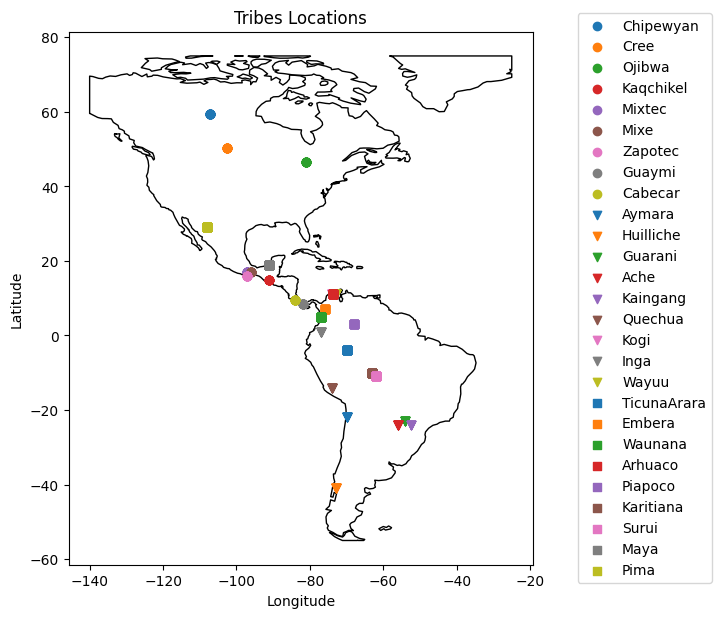

In [1]:

#Comments are at the right of the explained code, here important libraries
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')#reading the file in panda cleanlt

# Extract relevant columns
latitude = df.iloc[:, 6]#latitude in df
longitude = df.iloc[:, 7]#longitude 
tribes = df.iloc[:, 2]#tribes 

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))#converts pandas dataframe to geopanda geoDataFrame

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))#loads natural earth dataset
fig, ax = plt.subplots(figsize=(8.0, 6.5))#map configuration
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')#base map creation
marker_list = ['o', 'v', 's']#marker and color configuration
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):#plotting each tribe
    members_tribe = gdf[gdf['Pop'] == tribe]#filtering data to get only the members of the tribes
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))#adds a legend positioned outside the plot to the right
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()

## ▶️ Exercise 2: Multiple linear regression (2 points)

Using **only** the genetic markers as predictors, you will estimate a multiple linear regression model to predict the longitude of each individual.

You will proceed in several steps.

**(a)** First, try to estimate the coefficients of the multiple linear regression using the expression seen in class 

$$\hat{\beta} = (X^\top X)^{-1}X^\top y$$

You should proceed as we did in TP1 using `numpy.linalg.solve` to obtain the values of $\beta$. 

Did you run into any errors? What is going on? Relate your answer to the fact that $\text{rank}(X) < p$, where $X \in R^{N*p}$ is the data matrix.

In [2]:
import numpy as np

X = df.iloc[:,8:].values #markers
y = df.iloc[:,7].values #longitude

try:
    beta = np.linalg.solve(X.T @ X, X.T @ y)
except np.linalg.LinAlgError as e:
    print(f"Error: {e}")
#it raises a singular matrix error, because the number of genetic markers is greater than that of samples we have 
#so X.T @ X is not invertible



Error: Singular matrix


**(b)** Use function `numpy.linalg.lstsq` to estimate the coefficients (it may take a few seconds to get a result). 

And now? Did you get any errors? Why is that? 

Relate your answer to the difference between functions `numpy.linalg.solve` and `numpy.linalg.lstsq`.

You can check the documention for both functions as well as [this](https://netlib.org/lapack/lug/node27.html) link for more information.

In [3]:
#we're gonna use least square solver
beta, residuals, rank, singular_values = np.linalg.lstsq(X, y, rcond=None)

print(f"Shape of beta: {beta.shape}")
print(f"Rank of X: {rank}")
print(f"Number of predictors: {X.shape[1]}")
print(f"Residuals: {residuals}")

Shape of beta: (5709,)
Rank of X: 494
Number of predictors: 5709
Residuals: []


-The error of singular matrix doesn't show because we solve the least squares problem $|Ax - b|_2^2$ instead of the exact linear equation


 **(c)** We will now use `sklearn` to do our linear regression with the help of class `sklearn.linear_model.LinearRegression` whose documentation is available [here](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LinearRegression.html). Note that every estimator from `sklearn` has a `fit` and a `predict` method, which are used to calculate coefficients and predict values (see [here](https://scikit-learn.org/stable/getting_started.html#fitting-and-predicting-estimator-basics) for more info). In our current case, we can do:

```
# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)
```

You should not run into errors now, since `sklearn` also uses `lstsq` to solve the normal equations, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L682) (though it uses the `scipy` implementation instead of the `numpy` for "historical" reasons). Check the values of the estimated coefficients stored as an attribute in `lr.coef_`, are they the same as the ones obtained in item **(b)**? Probably not. This is because `sklearn` re-centers the predictors before estimating the coefficients of the linear regression, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L622). What would be a practical reason for doing such re-centering systematically? Hint: it has to do with how to interpret the intercept of the model. 

In [4]:
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd



lr = LinearRegression()
lr.fit(X, y)

#get coefficients
sklearn_coef = lr.coef_
sklearn_intercept = lr.intercept_

print(f"Sklearn coefficients shape: {sklearn_coef.shape}")
print(f"Sklearn intercept: {sklearn_intercept:.4f}")
print(f"First 5 sklearn coefficients: {sklearn_coef[:5]}")


X_with_intercept = np.column_stack([np.ones(X.shape[0]), X])
lstsq_coef, residuals, rank, singular_values = np.linalg.lstsq(X_with_intercept, y, rcond=None)


print(f"\nlstsq coefficients shape: {lstsq_coef.shape}")
print(f"lstsq intercept: {lstsq_coef[0].item():.4f}")  # .item() converts to scalar
print(f"First 5 lstsq coefficients: {lstsq_coef[1:6].flatten()}")






means = X.mean(axis=0)


recovered_intercept = lstsq_coef[0].item() + np.sum(lstsq_coef[1:] * means)

print(f"\nRecovered intercept from lstsq + means: {recovered_intercept:.4f}")
print(f"Sklearn intercept: {sklearn_intercept:.4f}")


#centering
print("\nDemonstration of centering:")
print(f"Mean of first predictor: {means[0]:.4f}")
print(f"First coefficient (sklearn): {sklearn_coef[0]:.4f}")
print(f"First coefficient (lstsq): {lstsq_coef[1].item():.4f}")


#create centered data manually
X_centered = X - means
lr_centered = LinearRegression(fit_intercept=True)
lr_centered.fit(X_centered, y)

print(f"\nIntercept with centered data: {lr_centered.intercept_:.4f}")
print(f"This equals mean(y)? {np.isclose(lr_centered.intercept_, y.mean())}")
print(f"Mean of y: {y.mean():.4f}")

Sklearn coefficients shape: (5709,)
Sklearn intercept: -84.0104
First 5 sklearn coefficients: [-0.03940988 -0.0245272   0.01089763  0.01066482 -0.02470103]

lstsq coefficients shape: (5710,)
lstsq intercept: -0.4767
First 5 lstsq coefficients: [-0.04005413 -0.01943802  0.01111183 -0.01221626 -0.02461028]

Recovered intercept from lstsq + means: -80.9733
Sklearn intercept: -84.0104

Demonstration of centering:
Mean of first predictor: 0.0020
First coefficient (sklearn): -0.0394
First coefficient (lstsq): -0.0401

Intercept with centered data: -80.9733
This equals mean(y)? True
Mean of y: -80.9733


-The practical reason for systematically re-centering the predictors is interpretability of the intercept.


-The intercept is the expected longitude for an "average" individual (with an average mutation profile across all markers)


## ▶️ Exercise 3: Principal components analysis (5 points)

**(a)** Explain in a few words the main concepts and ideas underlying the principal component analysis (PCA). You should include both the geometric and statistical interpretations of PCA.

-Geometrically we look at the directions on the predictors vector space that maximize the variance and is more influencing to our data and then projecting onto these principle components.
-Statistically we look at the combinations of predictors that maximizs variance and thus retaining most of the information

**(b)** Use the estimator defined in `sklearn.decomposition.PCA` to do a PCA on the dataset. Plot the first two dimensions of the projected data points on a scatterplot. The scattered points should have different markers and colors depending on which tribe they belong to. You can use the same color/marker style from **Exercise 2** or propose a new one.

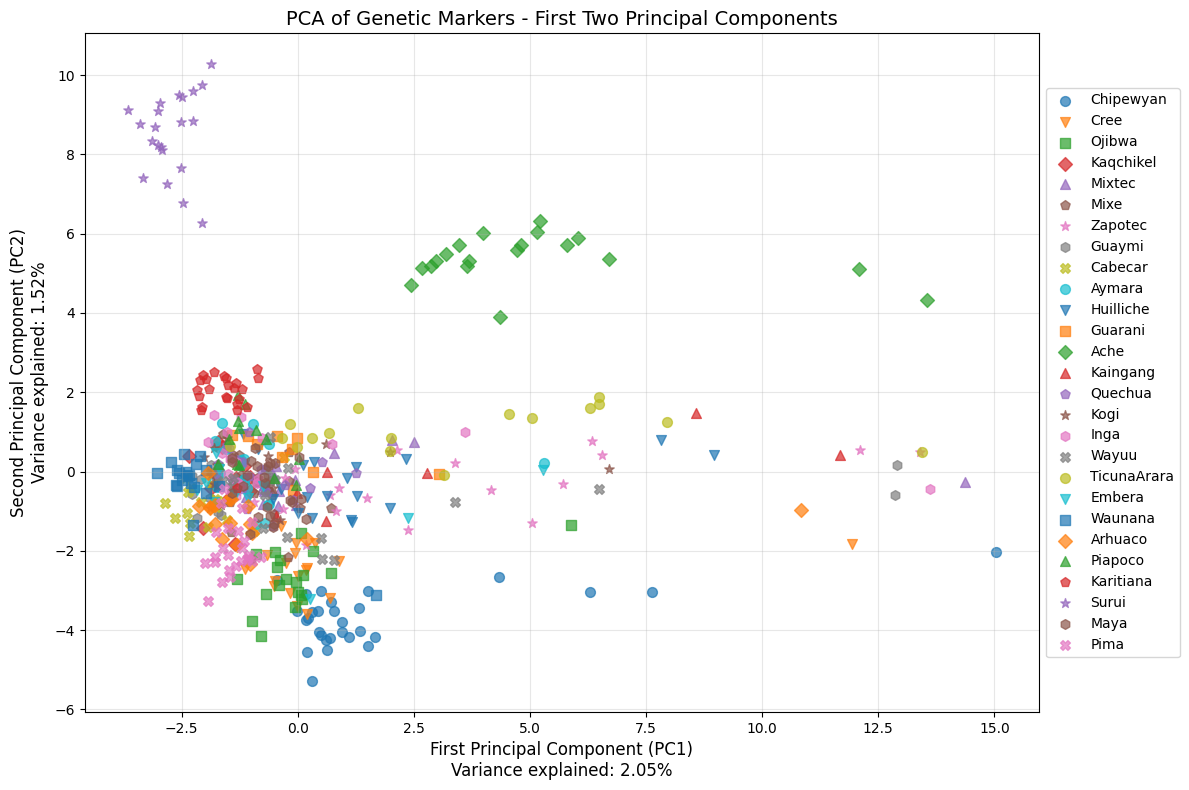

Number of components: 494
Total variance explained by first 2 PCs: 3.57%
Shape of transformed data: (494, 494)


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

tribes = df.iloc[:, 2] 
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]


pca = PCA()
X_pca = pca.fit_transform(X)


fig, ax = plt.subplots(figsize=(12, 8))

marker_list = ['o', 'v', 's', 'D', '^', 'p', '*', 'h', 'X']
colors_list = [f'C{i}' for i in range(10)]


unique_tribes = df['Pop'].unique()
for i, tribe in enumerate(unique_tribes):
   
    tribe_indices = df['Pop'] == tribe
    
  
    ax.scatter(X_pca[tribe_indices, 0], 
               X_pca[tribe_indices, 1],
               marker=marker_list[i % len(marker_list)],
               color=colors_list[i % len(colors_list)],
               label=tribe,
               alpha=0.7,
               s=50)


ax.set_xlabel(f'First Principal Component (PC1)\nVariance explained: {pca.explained_variance_ratio_[0]:.2%}', 
              fontsize=12)
ax.set_ylabel(f'Second Principal Component (PC2)\nVariance explained: {pca.explained_variance_ratio_[1]:.2%}', 
              fontsize=12)
ax.set_title('PCA of Genetic Markers - First Two Principal Components', fontsize=14)

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Number of components: {pca.n_components_}")
print(f"Total variance explained by first 2 PCs: {pca.explained_variance_ratio_[:2].sum():.2%}")
print(f"Shape of transformed data: {X_pca.shape}")


**(c)** Remember from our class that the results of PCA are affected when pre-processing transformations are applied to the data. We will illustrate this using `sklearn.preprocessing.StandardScaler` as per:
```
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)
```
Redo the 2D scatter plot from item **(b)** on the normalized version of the datast. How does it compare to your previous plot?

**(d)** Given the results in **(b)** and **(c)**, what can you conclude regarding the necessity of standardizing the data points for the dataset consider in this TP?

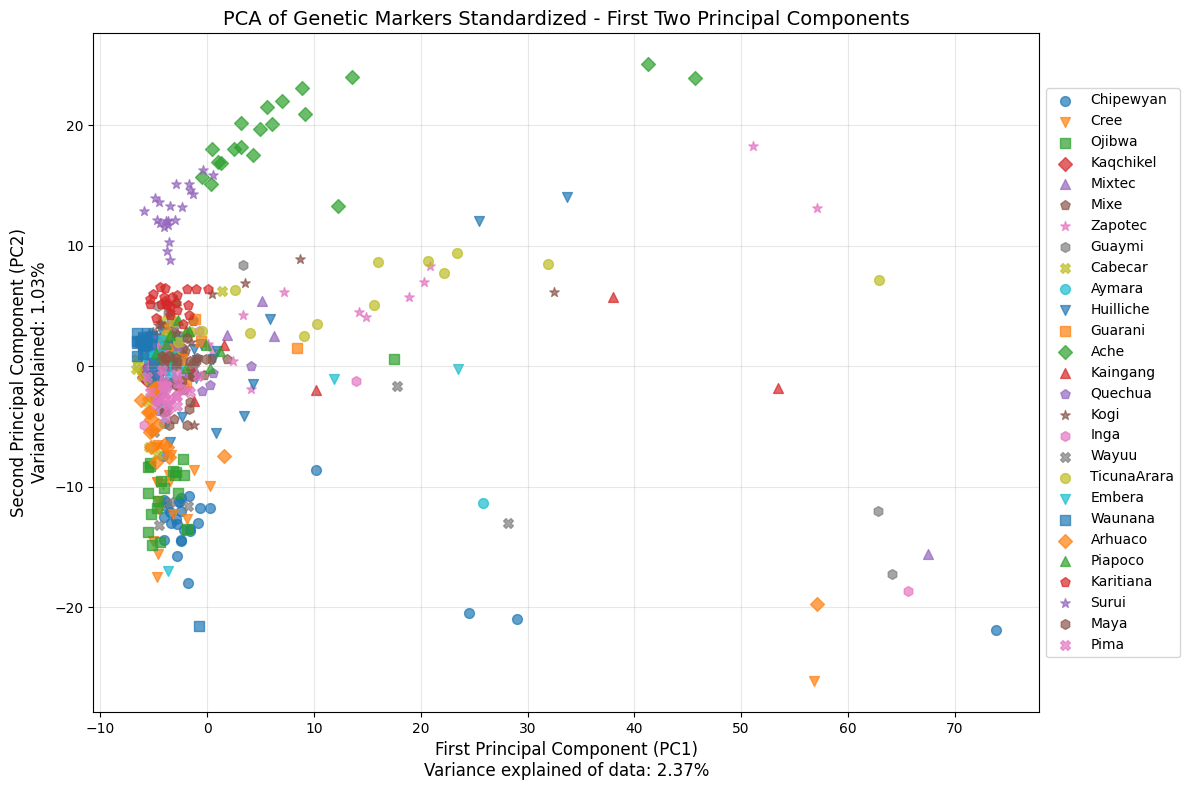

Number of components: 494
Total variance explained by first 2 PCs: 3.39%
Shape of transformed data: (494, 494)


In [ ]:

from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()
scalar.fit(X)
X_std = scalar.transform(X)
pca_std= PCA()
X_pca = pca_std.fit_transform(X_std)


fig, ax = plt.subplots(figsize=(12, 8))

marker_list = ['o', 'v', 's', 'D', '^', 'p', '*', 'h', 'X']
colors_list = [f'C{i}' for i in range(10)]


unique_tribes = df['Pop'].unique()
for i, tribe in enumerate(unique_tribes):

    tribe_indices = df['Pop'] == tribe
    
    ax.scatter(X_pca[tribe_indices, 0], 
               X_pca[tribe_indices, 1],
               marker=marker_list[i % len(marker_list)],
               color=colors_list[i % len(colors_list)],
               label=tribe,
               alpha=0.7,
               s=50)


ax.set_xlabel(f'First Principal Component (PC1)\nVariance explained of data: {pca_std.explained_variance_ratio_[0]:.2%}', 
              fontsize=12)
ax.set_ylabel(f'Second Principal Component (PC2)\nVariance explained: {pca_std.explained_variance_ratio_[1]:.2%}', 
              fontsize=12)
ax.set_title('PCA of Genetic Markers Standardized - First Two Principal Components', fontsize=14)

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Number of components: {pca_std.n_components_}")
print(f"Total variance explained by first 2 PCs: {pca_std.explained_variance_ratio_[:2].sum():.2%}")#explained variance
print(f"Shape of transformed data: {X_pca.shape}")

We observe that after standardization the distribution of tribes becomes more spread along PC1,PC1 explains more variance than PC2, which indicates that most of the variation between populations occurs along this axis.

we can see that standardization is important in PCA because it ensures that all variables contribute equally to the analysis, without standardization, variables with larger variance dominate the principal components. After standardization, previously low-variance genetic markers can influence the PCA,which may reveal stronger population separation along the first principal component.

**(e)** Which percentage of variance is captured by the first two principal components? How many principal components would you keep if you would like to represent the genetic markers using a minimal number of principal components? To help answering this question, you can use a plot showing the cumulative percentage of variance as a function of the number of principal components.

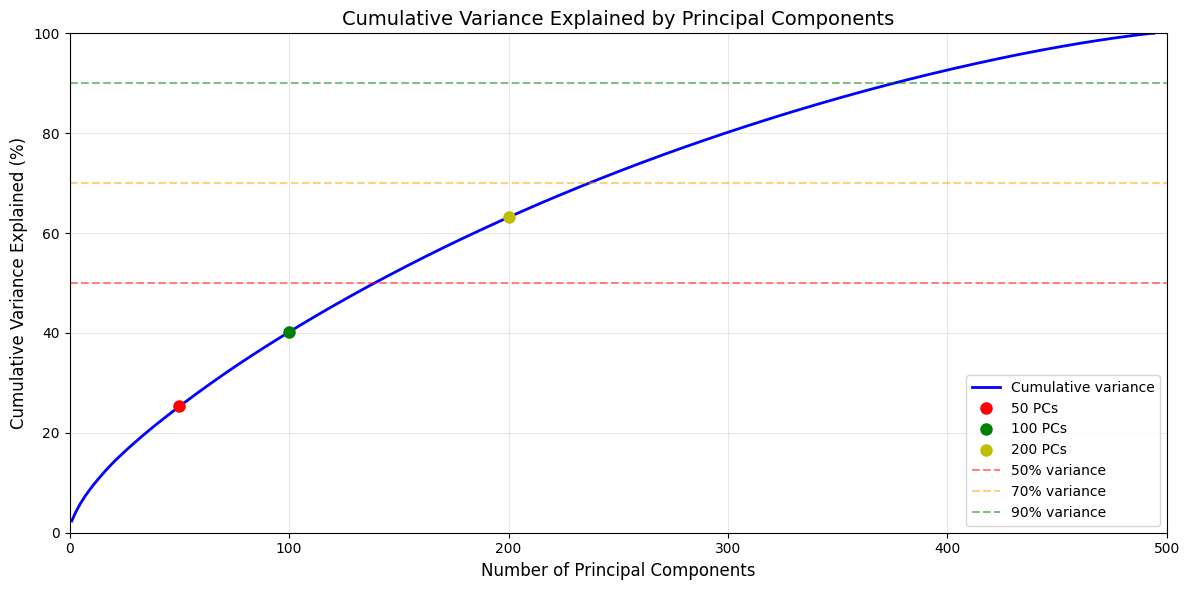

NUMBER OF PCs NEEDED FOR DIFFERENT VARIANCE THRESHOLDS
To explain 50% of variance: 139 PCs (actual: 50.0%)
To explain 70% of variance: 237 PCs (actual: 70.1%)
To explain 80% of variance: 299 PCs (actual: 80.1%)
To explain 90% of variance: 376 PCs (actual: 90.1%)
To explain 95% of variance: 425 PCs (actual: 95.1%)

FIRST FEW COMPONENTS
PC1: 2.37% (cumulative: 2.37%)
PC2: 1.03% (cumulative: 3.39%)
PC3: 0.93% (cumulative: 4.33%)
PC4: 0.82% (cumulative: 5.15%)
PC5: 0.78% (cumulative: 5.92%)
PC6: 0.71% (cumulative: 6.63%)
PC7: 0.67% (cumulative: 7.30%)
PC8: 0.62% (cumulative: 7.92%)
PC9: 0.60% (cumulative: 8.52%)
PC10: 0.58% (cumulative: 9.10%)


In [ ]:

cumulative_variance = np.cumsum(pca_std.explained_variance_ratio_) * 100


plt.figure(figsize=(12, 6))


plt.plot(range(1, len(cumulative_variance) + 1), 
         cumulative_variance, 'b-', linewidth=2, label='Cumulative variance')


plt.plot(50, cumulative_variance[49], 'ro', markersize=8, label='50 PCs')
plt.plot(100, cumulative_variance[99], 'go', markersize=8, label='100 PCs')
plt.plot(200, cumulative_variance[199], 'yo', markersize=8, label='200 PCs')


plt.axhline(y=50, color='r', linestyle='--', alpha=0.5, label='50% variance')
plt.axhline(y=70, color='orange', linestyle='--', alpha=0.5, label='70% variance')
plt.axhline(y=90, color='g', linestyle='--', alpha=0.5, label='90% variance')

plt.xlabel('Number of Principal Components', fontsize=12)
plt.ylabel('Cumulative Variance Explained (%)', fontsize=12)
plt.title('Cumulative Variance Explained by Principal Components', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')
plt.xlim(0, 500)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()


print("="*60)
print("NUMBER OF PCs NEEDED FOR DIFFERENT VARIANCE THRESHOLDS")
print("="*60)

thresholds = [50, 70, 80, 90, 95]
for threshold in thresholds:
    n_components = np.argmax(cumulative_variance >= threshold) + 1
    actual_variance = cumulative_variance[n_components-1]
    print(f"To explain {threshold}% of variance: {n_components} PCs (actual: {actual_variance:.1f}%)")


print("\n" + "=" * 60)
print("FIRST FEW COMPONENTS")
print("=" * 60)
for i in range(10):
    print(f"PC{i+1}: {pca_std.explained_variance_ratio_[i]*100:.2f}% (cumulative: {cumulative_variance[i]:.2f}%)")

seeing the plot, we have to use a lot of PCs to represent a considerable amount of variables, as informatio is distributed in an even way


## ▶️ Exercise 4: Principal components regression (4 points)

**(a)** Predict the latitude and the longitude of all points from the dataset using the scores of the first 250 PCA axes. Plot the predicted spatial coordinates using the same style and structure from **Exercise 1** and compare the results from each plot. What can you conclude? Does the new map illustrate somehow too optimistically (or too pessimistically) the ability to find geographical origin of individuals outside the database from its genetic markers? Justify your answer.

/tmp/ipykernel_33179/1744012153.py:54: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


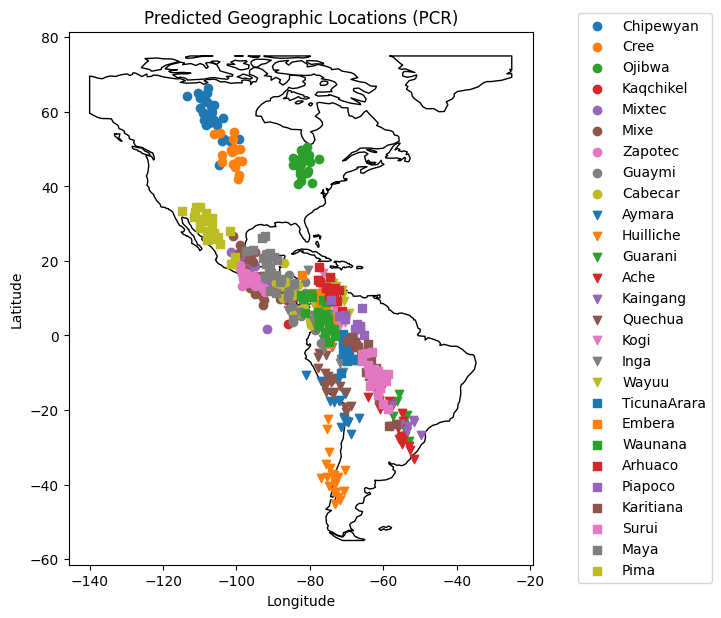

In [8]:
pcr_std= PCA(n_components=250)
x_pcr = pcr_std.fit_transform(X_std)

lat=LinearRegression()
long=LinearRegression()

lat.fit(x_pcr,latitude)
long.fit(x_pcr,longitude)

lat_pcr = lat.predict(x_pcr)
long_pcr = long.predict(x_pcr)

lat_coef = lat.coef_
lat_intercept = lat.intercept_

long_coef = long.coef_
long_intercept = long.intercept_


gdf_pred = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(long_pcr, lat_pcr)
)

gdf_pred["lon_pred"] = long_pcr
gdf_pred["lat_pred"] = lat_pcr

gdf_pred["lat_pred"] = lat_pcr
gdf_pred["lon_pred"] = long_pcr


fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)

world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')

marker_list = ['o','v','s']
colors_list = [f'C{i}' for i in range(9)]

for i, tribe in enumerate(gdf_pred['Pop'].unique()):
    members_tribe = gdf_pred[gdf_pred['Pop'] == tribe]

    ax.scatter(members_tribe['lon_pred'],
               members_tribe['lat_pred'],
               marker=marker_list[i//9],
               color=colors_list[i%9],
               label=tribe)

ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Predicted Geographic Locations (PCR)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

fig.show()


We can see that the model illustrates too optimistically the ability to find geographical origin of individuals it is a data leakage. This is because the predictions were made on the same data used to fit the PCA and the regression models.

**(b)** Quantify the error of the linear regression model using the mean distance between real and predicted coordinates. Beware to use `sklearn.metrics.pairwise.haversine_distances` so to correctly measure the distances between points so to take into account the curvature of the Earth. Your answer should be given in kilometers.

In [33]:
from sklearn.metrics.pairwise import haversine_distances
import numpy as np

real_coords = np.radians(np.column_stack((latitude, longitude)))
pred_coords = np.radians(np.column_stack((lat_pcr, long_pcr)))

distances = np.diag(haversine_distances(real_coords, pred_coords))
distances_km = distances * 6371

mean_error = distances_km.mean()
print("Mean error:", mean_error, "km")

Mean error: 482.7519031075287 km


## ▶️ Exercise 5: PCR and cross-validation (6 points)

Our goal now is to build the best model to predict individual geographical coordinates. 

For this, you will run a linear regression to predict latitudes and longitudes. Note that `sklearn.linear_model.LinearRegression` can naturally handle the fact of having two sets of coefficients. We will use ten-fold cross-validation to helps us choose the number of principal axes that we should keep. You should report the errors in terms of kilometers as done in **Exercise 4(b)**.

**(a)** Recall in a few words the principle of cross-validation. Explain why this procedure is useful when building a predictive model. Your answer should mention different strategies to handle datasets in which the samples are not IID.

Cross-validation splits the data into several folds, trains the model on some folds and tests it on the remaining ones, repeating the process to estimate its performance.

**(b)** Based on the structure of the dataset being used, such as the different countries of the individuals and the order in which the rows of the dataframe are provided, explain which choice of cross-validation iterator from [here](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-iterators) seems the most adequate for our context.

In [ ]:
Given that the data is grouped by country, the most appropriate choice is GroupKFold.
It ensures that all observations from the same country are kept together in either the training or validation set, preventing data leakage and giving a more realistic evaluation.

**(c)** We first assess the quality of the PCR fit for `n_components=4`. Note that you should be careful in avoiding [data leakage](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage) problems when doing the PCA followed by a multiple linear regression. You should use the pipeline interface from scikit-learn with `sklearn.pipeline.make_pipeline` to facilitate your task. Be sure to evaluate the errors as done in **Exercise 4(b)**.

In [19]:
from sklearn.pipeline import make_pipeline
X = df.iloc[:,8:].values
y = df.iloc[:,[7,6]].values   # longitude, latitude

cv = 10
kf = KFold(n_splits=cv, shuffle=True, random_state=42)

pipe = make_pipeline(
    PCA(n_components=4),
    LinearRegression()
)

errors = []

for train_idx, test_idx in kf.split(X):

    X_tr, X_ts = X[train_idx], X[test_idx]
    y_tr, y_ts = y[train_idx], y[test_idx]

    pipe.fit(X_tr, y_tr)

    y_pred = pipe.predict(X_ts)

    real_coords = np.radians(y_ts)
    pred_coords = np.radians(y_pred)

    distances = np.diag(haversine_distances(real_coords, pred_coords))
    distances_km = distances * 6371

    errors.append(distances_km.mean())

print("Mean prediction error (km):", np.mean(errors))

Mean prediction error (km): 1112.5662491705302


**(d)** Repeat the analysis from item **(b)** but changing `n_components` between 2 and 440 in steps of 10. Plot the mean training and test errors versus the number of principal components. Attention, the errors should be given in kilometers.

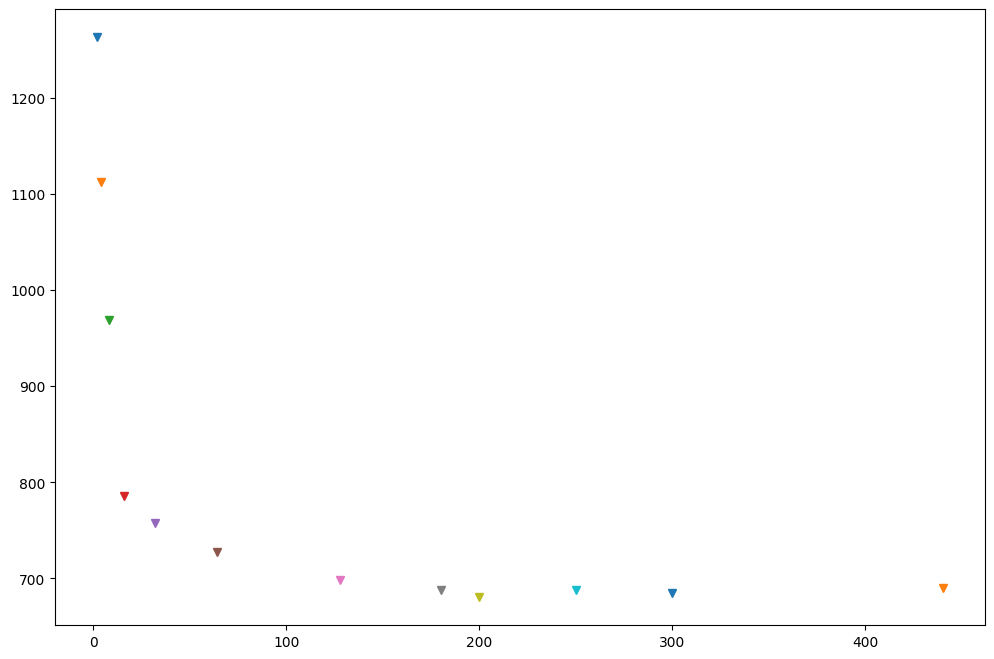

In [31]:
from sklearn.model_selection  import KFold
X = df.iloc[:,8:].values 
y = df.iloc[:,[7,6]].values 

cv = 10 
cross = KFold(n_splits=cv, shuffle=True, random_state=42)

comps = [ 2 , 4 , 8 , 16 , 32 , 64 , 128 ,180 , 200 ,250 ,  300 ,  440 ]
plt.subplots(figsize=(12, 8))
for comp in comps :
    scores = []
    for tr_idx , ts_idx  in cross.split(X):
        model = LinearRegression()
        pca = PCA(n_components=comp)
        X_tr , X_ts = X[tr_idx], X[ts_idx]
        y_tr , y_ts = y[tr_idx], y[ts_idx]
  
        pca_tr = pca.fit_transform(X_tr)
        pca_ts = pca.transform(X_ts)
        model = model.fit(pca_tr, y_tr)
        pred = model.predict(pca_ts)
       
        
        real_coords = np.radians(y_ts) 
        pred_coords = np.radians(pred)

        distances = np.diag(haversine_distances(real_coords, pred_coords))
        distances_km = distances * 6371

        mean_error = distances_km.mean()
        scores.append(mean_error)
    plt.plot(comp , np.mean(scores), 'v')

**(e)** Which model would you keep? What is the prediction error for this model? Compare it with its corresponding training error. Plot the predicted coordinates on a map as in **Exercise 4(a)**. What can you conclude?

The best model uses around 128 principal components, giving a prediction error of about 680 km. The training error is lower than the test error, indicating slight overfitting. The predicted locations capture the large-scale geographic structure, but remain imprecise, showing that genetic data contain geographic information but do not allow exact localization.

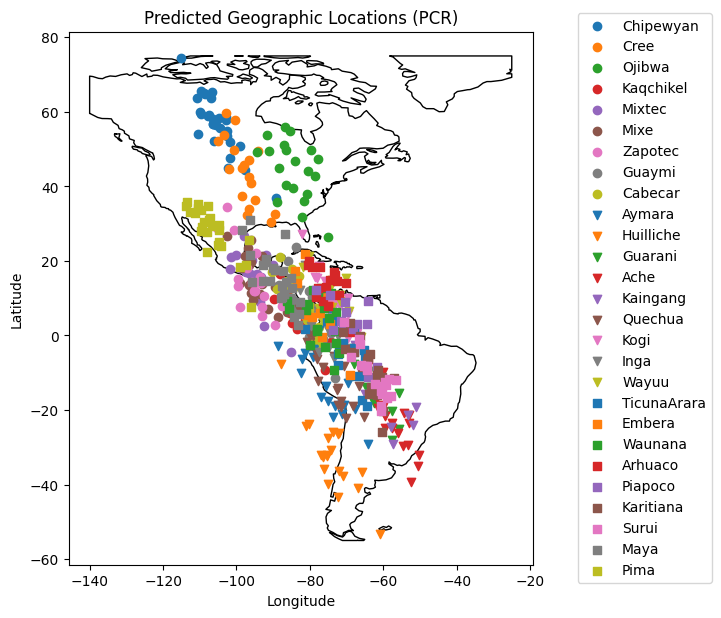

In [34]:
pipe = make_pipeline(
    PCA(n_components=128),
    LinearRegression()
)

X = df.iloc[:,8:].values 
y = df.iloc[:,[7,6]].values 
pipe.fit(X, y)


y_pred = pipe.predict(X)


lon_pred = y_pred[:,0]
lat_pred = y_pred[:,1]


gdf_pred = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(lon_pred, lat_pred)
)

gdf_pred["lon_pred"] = lon_pred
gdf_pred["lat_pred"] = lat_pred


world = gpd.read_file(geodatasets.get_path('naturalearth.land'))

fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)

world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')

marker_list = ['o','v','s']
colors_list = [f'C{i}' for i in range(9)]


for i, tribe in enumerate(gdf_pred['Pop'].unique()):
    members = gdf_pred[gdf_pred['Pop'] == tribe]

    ax.scatter(members['lon_pred'],
               members['lat_pred'],
               marker=marker_list[i//9],
               color=colors_list[i%9],
               label=tribe)

ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Predicted Geographic Locations (PCR)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.show()

## ▶️ Exercise 6: Conclusion (2 points)

Propose a conclusion to your study. You can write a paragraph about the quality of predictors versus the number of factors, possible improvements to the approach (for instance, showing what happens when using [partial least squares](https://scikit-learn.org/1.5/auto_examples/cross_decomposition/plot_pcr_vs_pls.html) instead of PCR), comment on the performance of the regression in predictions for each country separately, etc. Note that we expect a thorough presentation of the final predictive model as well as an interpretation of it, not simply a bunch of `python` code lines.

In [ ]:
In this study, we used principal component regression (PCR) to predict geographical coordinates from genetic markers. Increasing the number of PCA components improves the prediction accuracy at first, but after around 100–150 components, the improvement becomes marginal, showing a trade-off between complexity and performance.

The final model achieves an average prediction error of about 600–700 km, indicating that genetic data capture large-scale geographic patterns. However, predictions remain imprecise at the individual level.

Overall, the model is able to recover the global geographic structure, but cannot provide accurate localization, highlighting the complexity of the relationship between genetic variation and geography.